## Introduction to Volatility Smile and Option Pricing

Volatility smile is a important concept in option pricing and risk management, reflecting how implied volatility varies across strikes and maturities, and how it can vary over time. Mastering its technical treatment requires advanced stochastic calculus, but its practical implications are essential for all options practitioners—quantitative analysts, traders, and structurers alike. In this assignment, we implement a stochastic volatility model (Heston) and a local volatility model (Dupire), exploring their properties and applications.

### Learning Outcomes
- **For Quants**: Gain hands-on experience implementing stochastic and local volatility models using Python, including Fourier transforms and Monte Carlo simulations.
- **For Traders/Structurers**: Understand how volatility smile shapes option prices, influences hedging strategies, and reflects market dynamics, even without coding the models.
- **For All**: Recognize key conventions (e.g., delta strikes) and interpret model outputs like implied volatility surfaces to inform trading decisions.


In [1]:
# just execute this cell to have the proper functions imported
# the cell must run correctly to be able to run the assignement
#
import json
import numpy as np
import pandas as pd
import numpy as np
import scipy.stats as si
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import datetime as dt
from io import StringIO
answers = {}



## Black and Black Scholes Framework


### Overview
The **Black formula** extends the Black-Scholes model to price options when the forward price $ F_t(T) $ adjusts for dividends ($ q $), storage costs, or convenience yields, rather than assuming a simple risk-neutral drift ($ F_t(T) = S_t e^{r(T-t)} $). It’s widely used for options on futures or dividend-paying assets.

### Learning Outcomes
- **Understand**: Why the Black formula is preferred for assets with income streams or futures, and how it simplifies pricing using forwards.
- **Interpret**: The roles of $ N(d_1) $ and $ N(d_2) $ as probabilities under different measures, bridging theory to intuition.
- **Apply**: Calculate option prices and implied volatilities, and identify key strikes (e.g., 25%, 50%, 75% delta) used in volatility smile analysis.

### Key Concepts
- **Black Formula**: $ C_{\text{Black}} = e^{-rT} [ F_0(T) N(d_1) - K N(d_2) ] $, using $ F_0(T) = S_0 e^{(r-q)T} $.
- **Black-Scholes**: Models spot price dynamics explicitly, $ C_{\text{BS}} = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2) $.
- **Moneyness**: 25%, 50%, and 75% delta strikes reveal volatility smile patterns, a standard in market practice.



### **Motivation for the Black Formula**  
The **Black formula** is particularly useful when the forward price $ F_t(T) $ (the agreed future price at time $ t $ for delivery at $ T $) **does not follow the simple risk-neutral drift $ r $** (i.e., $ F_t(T) \neq S_t e^{r(T-t)} $), but instead accounts for a dividend yield $ q $ or other adjustments:  
$$
F_t(T) = S_t e^{(r-q)(T-t)}.  
$$  
**Why it’s convenient**:  
- Works directly with $ F_t(T) $, avoiding explicit modeling of $ S_t $.  
- Handles cases where the cost-of-carry includes dividends ($ q $), storage costs, or convenience yields.  
- Used for **options on futures** (where $ F_t(T) $ is observable) or assets with income streams.  

---

### **Black-Scholes vs. Black Formula**  

#### **Black-Scholes (Spot Dynamics)**  
Under $ \frac{dS_t}{S_t} = (r - q)dt + \sigma dW_t $, the call price is:  
$$
C_{\text{BS}} = S_0 e^{-qT} N(d_1) - K e^{-rT} N(d_2),  
$$  
where:  
$$
d_1 = \frac{\ln(S_0/K) + (r - q + \sigma^2/2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}.  
$$

#### **Black Formula (Forward Dynamics)**  
For $ F_t(T) = S_t e^{(r-q)(T-t)} $, the forward follows $ \frac{dF_t(T)}{F_t(T)} = \sigma dW_t $ (no drift). The call price becomes:  
$$
C_{\text{Black}} = e^{-rT} \left[ F_0(T) N(d_1) - K N(d_2) \right],  
$$  
where:  
$$
d_1 = \frac{\ln(F_0(T)/K) + (\sigma^2/2)T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma \sqrt{T}.  
$$  
**Key Insight**:  
- Black-Scholes explicitly models $ S_t $ with drift $ r-q $.  
- Black uses $ F_0(T) = S_0 e^{(r-q)T} $, embedding $ q $ into the forward price.  

---

### **Advanced Topic: Interpretation of $ N(d_1) $ and $ N(d_2) $**  
#### **$ N(d_2) $: Risk-Neutral Probability of Call Exercise**  
$ N(d_2) $ is the probability $ \mathbb{Q}(S_T > K) $ under the **risk-neutral measure**:  
$$
N(d_2) = \mathbb{Q}\left( \ln S_T > \ln K \right).  
$$  
This arises from the term $ e^{-rT} K N(d_2) $, which discounts the strike payment weighted by the exercise probability.  

#### **$ N(d_1) $: Stock Measure Probability of Call Exercise**  
Under the **stock measure $ \mathbb{S} $** (where $ S_t e^{-qt} $ is the numeraire):  
$$
N(d_1) = \mathbb{E}^{\mathbb{S}}[\mathbf{1}_{S_T > K}],  
$$  
interpreting $ N(d_1) $ as the probability of $ S_T > K $ when the stock grows at $ r - q + \sigma^2 $ (Girsanov-adjusted drift).  

**Measure Change Details**:  
- The Radon-Nikodym derivative for $ \mathbb{Q} \to \mathbb{S} $ is $ \frac{d\mathbb{S}}{d\mathbb{Q}} = \frac{S_T e^{-qT}}{F_0(T)} $.  
- This introduces a drift adjustment $ +\sigma^2 $ to $ W_t $, linking $ N(d_1) $ to the stock measure.  

**Decomposition of Call Price**:  
$$
C = e^{-rT} \mathbb{E}^{\mathbb{Q}}[(S_T - K)^+] = e^{-rT} \left( F_0(T) N(d_1) - K N(d_2) \right).  
$$  
- **First term**: $ F_0(T) N(d_1) = F_0(T) \mathbb{E}^{\mathbb{S}}[\mathbf{1}_{S_T > K}] $.  
- **Second term**: $ K N(d_2) = K \mathbb{E}^{\mathbb{Q}}[\mathbf{1}_{S_T > K}] $.  

### **Moneyness: the 25%, 50% and 75% $\Delta$ strikes**  

The `black_strike_from_delta` function computes the strike price \( K \) corresponding to a given delta (e.g., $ P_1 = N(d_1) $) under the Black formula, such as the at-the-money (ATM) strike where $ P_1 = 0.5 $. This is particularly useful in practice because the volatility smile—the variation of implied volatility across strikes—is often quoted using put and call options with specific deltas. A common convention is to measure the smile at 25% delta points: a 25% delta call (where $ N(d_1) = 0.25 $) and a 25% delta put (where $ 1 - N(d_1) = 0.25 $, or $ N(d_1) = 0.75 $ for the equivalent call). These strikes highlight how volatility skews for out-of-the-money (OTM) options, offering a standardized way to compare market-implied volatilities across different assets and maturities.



---

### **Summary**  
1. **Black Formula**: Prices options using $ F_t(T) $, valid when $ F_t(T) \neq S_t e^{r(T-t)} $ (e.g., the forward grows with a rate shifted by $ q $).  
2. **$ N(d_2) $** and **$ N(d_1) $** have probabilistics interpretation as exercise probability under an appropriate numeraire.  
3. **Moneyness** of a strike can be expressed as a function of the implied $\Delta$ of the option.

The Black formulation is essential for pricing options on dividends-paying stocks, futures, and other underlyings with income adjustments. The interpretation of pricing as probability is an advanced topic that provides intuition for more general models. Moneyness is used by option traders to quote volatility.


In [2]:
def black_proba(F, K, T, r, sigma):
    """Black-Scholes N(d1) and N(d2) terms"""
    d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return np.array([si.norm.cdf(d1),si.norm.cdf(d2)])

def black_formula(F, K, T, r, sigma, iscallput='call'):
    """Computes the Black-Scholes price for European call or put options, vectorized."""
    F, K, T, r, sigma = map(np.asarray, [F, K, T, r, sigma])
    df = np.exp(-r * T)
    intrinsic_mask = (T < 1e-8) | (sigma * np.sqrt(T) < 1e-8)
    payoff = np.zeros_like(K, dtype=float)
    if iscallput.lower() not in ['call', 'put']: raise ValueError("iscallput must be 'call' or 'put'")
    intrinsic_payoff = np.maximum(F - K, 0) if iscallput.lower() == 'call' else np.maximum(K - F, 0)
    payoff = np.where(intrinsic_mask, intrinsic_payoff, payoff)
    not_intrinsic = ~intrinsic_mask
    if np.any(not_intrinsic):
        d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        bs_payoff = F * si.norm.cdf(d1) - K * si.norm.cdf(d2) if iscallput.lower() == 'call' else K * si.norm.cdf(-d2) - F * si.norm.cdf(-d1)
        payoff = np.where(not_intrinsic, bs_payoff, payoff)
    return payoff * df

def bisection_solver(f, xmin, xmax, xtol=1e-8, ytol=1e-8, maxiter=1000):
    """
    Finds a root of the function `f` using the bisection method.

    Parameters:
    - f: Function for which we seek f(x) = 0.
    - xmin, xmax: Initial interval bounds (must satisfy f(xmin) * f(xmax) < 0).
    - xtol: Tolerance for interval width (default: 1e-8).
    - ytol: Tolerance for function value (default: 1e-8).
    - maxiter: Maximum number of iterations (default: 1000).

    Returns:
    - x0: Approximate root such that |f(x0)| < ytol or |xmax - xmin| < xtol.
    - niter: Number of iterations performed.
    - success: True if a root was found within tolerances, False otherwise.
    """
    fmin = f(xmin)
    fmax = f(xmax)
    if fmin * fmax >= 0:
        return np.nan,0,False
    niter = 0
    while niter < maxiter:
        xmid = (xmin + xmax) / 2
        fmid = f(xmid)
        if abs(fmid) < ytol or (xmax - xmin) < xtol:
            return xmid, niter, True
        if fmid * fmin < 0:
            xmax = xmid
            fmax = fmid
        else:
            xmin = xmid
            fmin = fmid
        niter += 1
    raise Exception("Max iter reached")

def black_implied_vol(F, K, T, r, premium, iscallput='call'):
    f = lambda x: black_formula(F, K, T, r, x, iscallput='call')-premium
    x0, niter, success = bisection_solver(f, xmin=0, xmax=1, xtol=1e-9, ytol=1e-8)
    return x0
    
def black_strike_from_delta(F, Delta, T,sigma):
    """Black-Scholes K s.t. N(d1)=P1=Delta"""
    return F*np.exp(-si.norm.ppf(Delta)*sigma * np.sqrt(T)+(0.5 * sigma**2) * T)


# Example usage
S0 = 535
K = 535.0    # Strike
T = 1.0      # 1 year to maturity
r = 0.045     # 5% risk-free rate
q = 0.02
F = S0*np.exp((r-q)*T) # forward
sigma = 0.2  # 20% volatility
call  = black_formula(F, K, T, r, sigma, iscallput='call')
impliedsigma = black_implied_vol(F, K, T, r, premium=call, iscallput='call')
Katm  = black_strike_from_delta(F, 0.5, T, sigma)
P1,P2 = black_proba(F, F, T, r, sigma)
print(call,sigma,Katm,F,S0,P1)
answers["black formula forward is"] = F             # <- edit this line
answers["black formula implied volatility is"] = impliedsigma # <- edit this line 
answers["black formula atm strike (50% delta) is"] = Katm # <- edit
answers["black scholes delta at forward is"] = P2      # <- edit
answers['Why do traders use 25% and 75% delta strikes?'] = "because these strikes highlight how volatility skews for out-of-the-money (OTM) options, offering a standardized way to compare market-implied volatilities across different assets and maturities."

48.050882181282994 0.2 559.6249050511636 548.5435894805695 535 0.539827837277029


## Stochastic Volatility: The Heston Model

### Overview
In real markets, volatility isn’t constant—it fluctuates unpredictably. The Heston model (1993) captures this by treating volatility as a stochastic process tied to stock prices, explaining phenomena like the volatility smile and term structure. We’ll use Fourier transforms to price options and explore its implications.

Picture yourself pricing options in a market where volatility fluctuates unpredictably, unlike the static world of Black-Scholes. Enter the Heston model, crafted by Steven Heston in 1993, which embraces this reality by modeling volatility as a stochastic process linked to stock prices. For you, it’s a key to understanding how options capture market dynamics, explaining the volatility smile’s varied shapes and the term structure across maturities and strikes. Today, we’ll explore its Fourier transform-based solutions, connecting theory to practical pricing power.

The reference article is [Heston 1993](https://www.jstor.org/stable/2962057).


### Heston Model SDE for $S_t$ and $v_t$

The Heston model describes the dynamics of a stock price $S_t$  as follows
$$dS_t = (r-q) S_t \, dt + \sqrt{v_t} S_t \, dW_{1,t}$$
where its stochastic variance $v_t$ under the risk-neutral measure follows:
$$dv_t = \kappa (\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_{2,t}$$
where:
- $S_t$: Stock price at time $t$,
- $v_t$: Variance at time $t$,
- $r$: Risk-free rate,
- $q$: Dividend yield and equity repo rate,
- $\kappa$: Mean reversion rate of variance,
- $\theta$: Long-term variance,
- $\xi$: Volatility of variance,
- $dW_{1,t} dW_{2,t}=\rho dt$ Brownian motions correlation.

This SDE captures stochastic volatility, where $v_t$ follows a Cox-Ingersoll-Ross (CIR) process, and the stock price has volatility proportional to $\sqrt{v_t}$.

### Transformation to $x_t = \ln S_t$ and $v_t$

We can work with the log-price, define $x_t = \ln S_t$. Applying Ito's formula, 
the system becomes:
- $dx_t = \left( r - q - \frac{1}{2} v_t \right) dt + \sqrt{v_t} \, dW_{1,t}$,
- $dv_t = \kappa (\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_{2,t}$,

### Call Pricing with $P_1$ and $P_2$

The Heston model prices a European call option using the probabilities $P_1$ and $P_2$.
The call price: $$C = S_0 e^{-q T} P_1 - K e^{-r T} P_2$$
where:
- $P_1 = P^S(S_T > K )$: Exercise probability under the stock Numeraire $S_t$
- $P_2 = P^r(S_T > K)$: Exercise probability under risk neutral numeraire $M_t=e^{rt}$.

These probabilities are equivalent to $N(d_1)$ and $N(d_2)$ in the Black-Scholes model, where call price is given by: $$C = S_0 e^{-q T} N(d_1) - K e^{-r T} N(d_2)$$


### Heston's Formula for $P_1$ and $P_2$
The Heston model does not have a closed form solution, $P_1$ and $P_2$ are computed via Fourier inversion:
$$
P_j = \frac{1}{2} + \frac{1}{\pi} \int_0^\infty \text{Re} \left[ \frac{e^{-i \phi \ln K} f_j(\phi)}{i \phi} \right] d\phi, \quad j = 1, 2, i^2=-1
$$
where $f_j(\phi) = \mathbb{E}[e^{i \phi \ln S_T} | S_0, v_0]$ is the characteristic function of $\ln S_T$.

The characteristic function is:
$$
f_j(\phi) = e^{C(\phi) + D(\phi) v_0 + i \phi \ln S_0},
$$
where:
- $C(\phi) = r \phi i T + \frac{\kappa \theta}{\xi^2} \left[ (b_j - \rho \xi \phi i + d) T - 2 \ln \left( \frac{1 - g e^{d T}}{1 - g} \right) \right]$,
- $D(\phi) = \frac{b_j - \rho \xi \phi i + d}{\xi^2} \frac{1 - e^{d T}}{1 - g e^{d T}}$,
- $d = \sqrt{(b_j - \rho \xi \phi i)^2 - \xi^2 (2 u_j \phi i - \phi^2)}$,
- $g = \frac{b_j - \rho \xi \phi i + d}{b_j - \rho \xi \phi i - d}$,
- $b_1 = \kappa - \rho \xi$, $b_2 = \kappa$,
- $u_1 = 1/2$, $u_2 = -1/2$.

### Learning Outcomes
- **Understand**: How stochastic volatility generates volatility smiles and differs from Black-Scholes’ flat volatility.
- **Analyze**: Interpret implied volatility shapes (flat, skewed, or smiled) based on model parameters like correlation ($ \rho $).
- **Apply**: Price options and visualize volatility surfaces to assess market behavior across strikes and maturities.

### Key Features
- **SDEs**: Stock price $ dS_t = (r-q) S_t dt + \sqrt{v_t} S_t dW_{1,t} $, variance $ dv_t = \kappa (\theta - v_t) dt + \xi \sqrt{v_t} dW_{2,t} $.
- **Pricing**: Call price $ C = S_0 e^{-qT} P_1 - K e^{-rT} P_2 $, computed via Fourier inversion.



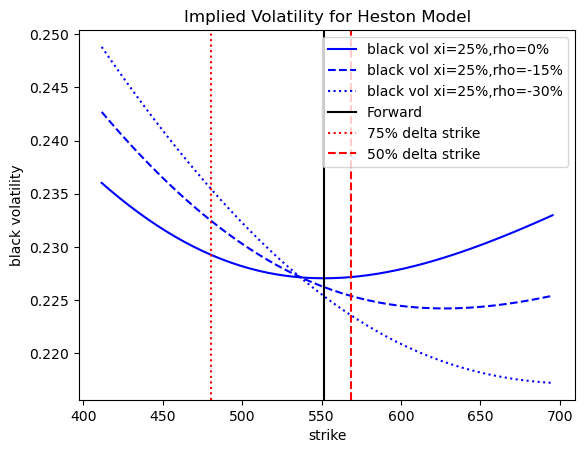

In [9]:

def compute_heston_proba(kappa,theta,xi,rho,r,T,v0,S0,K,params):
    """
    Compute Heston model probabilities P1 and P2 via Fourier inversion.
    
    Args:
        kappa: Mean reversion speed of variance
        theta: Long-term mean variance
        xi: Volatility of volatility
        rho: Correlation between asset and variance processes
        r: Risk-free rate
        T: Time to maturity
        v0: Initial variance
        S0: Initial asset price
        K: Strike price
        params: Dictionary of optional parameters:
               - ninteg: Number of integration points (default: 1000)
               - maxPhi: Upper integration limit (default: 50)
    
    Returns:
        Array of probabilities [P1, P2]
    """
    assert xi > 0, "Volatility of volatility (xi) must be positive"
    assert 2*kappa*theta>xi**2, "Feller conditions must be verified"
    assert abs(rho) <= 1, "Correlation rho must be in [-1, 1]"
    ninteg = params.get("ninteg",1000)
    maxPhi = params.get("maxPhi",100)
    quad   = params.get("quad","simpson")
    x0,lnK,tau = np.log(S0),np.log(K),T
    u = np.array([0.5, -0.5])  # Shape (2,)
    a = kappa * theta
    b = np.array([kappa - rho * xi, kappa])  # Shape (2,)
    i = 1j  # Imaginary unit
    Phi    = np.linspace(1e-8, maxPhi, ninteg).reshape(-1, 1)  # Shape (ninteg, 1) for column vector
    brhoxiPhii = b-rho*xi*Phi*i
    d = np.sqrt((brhoxiPhii)**2 - xi**2 * (2 * u * Phi * i - Phi**2))
    g = (brhoxiPhii + d) / (brhoxiPhii - d)
    C = r*Phi*i*tau + a/(xi**2) *((brhoxiPhii+d)*tau - 2 * np.log((1-g*np.exp(d*tau))/(1-g)))
    D = (brhoxiPhii+d)/(xi**2) * (1-np.exp(d*tau))/(1-g*np.exp(d*tau))
    f = np.exp(C+D*v0+i*Phi*x0)
    integrand = np.exp(-i*Phi*lnK)*f/(i*Phi) # Shape (ninteg,2)
    if quad=="simpson":
        integral  = simpson(np.real(integrand),Phi,axis=0) # shape (1,2)
    else:
        integral  = np.trapezoid(np.real(integrand),Phi,axis=0) # shape (1,2)
    if False:
        plt.plot(Phi,np.real(integrand)[:,0],label="P1")
        plt.plot(Phi,np.real(integrand)[:,1],label="P2")
        plt.legend()
        plt.show()
    P = 0.5 + 1/np.pi * integral 
    return P 
  
def heston_call_price(S0, K, T, r, q, v0, kappa, theta, xi, rho,params={}):
    P = compute_heston_proba(kappa,theta,xi,rho,r-q,T,v0,S0,K,params=params)
    return S0*np.exp(-q*T)*P[0]-K*np.exp(-r*T)*P[1]

black_proba(F, K, T, r, sigma)
# Example usage
S0    = 535.0
r     = 0.05
q     = 0.02
T     = 1.0
F     = S0*np.exp((r-q)*T)
K     = 535.0
sigma = 0.25
v0    = sigma**2
kappa = 1.0    # mean reversion speed
theta = 0.2**2 # vol at t=infty
xi    = 1*sigma
rho   = -0.1

# The code below prices call options at different strikes and times using Heston model
# The it computes implied volatility model using the black model
#
strikes = np.linspace(S0/1.3,S0*1.3)
sigma_bs_rho = {}
ls = ["-","--",":"]
for i,rho in enumerate([0, -0.15, -0.3]):
    sigma_bs_rho[rho] = []
    for K in strikes:
        call_heston = heston_call_price(S0, K, T, r, q, v0, kappa, theta, xi, rho)
        sigma_bs_rho[rho].append(black_implied_vol(F, K, T, r, premium=call_heston, iscallput='call'))
    plt.plot(strikes,sigma_bs_rho[rho],label="black vol xi=%.0f%%,rho=%.0f%%" % (xi*100,rho*100),linestyle=ls[i],color="blue")
plt.axvline(x=F,label="Forward",color="black",linestyle="-")
plt.axvline(x=black_strike_from_delta(F, .25, T,  sigma),label="25% delta strike",color="r",linestyle=":")
plt.axvline(x=black_strike_from_delta(F, .75, T, sigma),label="75% delta strike",color="r",linestyle=":")
plt.axvline(x=black_strike_from_delta(F, .5, T, sigma),label="50% delta strike",color="r",linestyle="--")
plt.xlabel("strike")
plt.legend()
plt.ylabel("black volatility")
plt.title("Implied Volatility for Heston Model")
plt.show()
answers["how does higher xi affect OTM put vol with same ATM?"] = "higher"
answers["how does negative rho affect OTM put vol with same ATM?"] = "lower"
answers['How does a negative rho impact option pricing?'] = "decrease option prices"
answers["implied volatility smile shape if rho=0"] = "smiled"
answers["implied volatility smile shape if rho=-15%"] = "skew"
answers["implied volatility smile shape if rho=-35%"] = "skew"

answers["implied volatility drift if v0<theta"] = "upward"
answers["implied volatility drift if v0>theta"] = "downward"

answers["implied volatility smile if xi=0 is"] = "flat"

answers["for rho=0, implied volatility ATM is"] = 0.2275 # <- approximate value
answers["for rho=-30%, implied volatility ATM is"] = 0.224 # <- approximate value

answers["for rho=0, implied volatility @25% put delta is"] = 0.23 # <- approximate value
answers["for rho=-30%, implied volatility @25% put delta is"] = 0.235 # <- approximate value


## Heston Volatility Surface

For a given set of Heston model parameters, we can price calls at various maturities and strikes and compute the implied black volatility surface. 

The Heston formula is unfortunately much less of a closed form than Black Formula, and the evaluation of $P_1$ and $P_2$ for all its brilliance, is a complex integral from 0 to infinity, where the denominator tends to 0. It appears to be less reliable for short tenors and far ITM or OTM strikes.

We use the formula only for maturities above $T=0.8$.

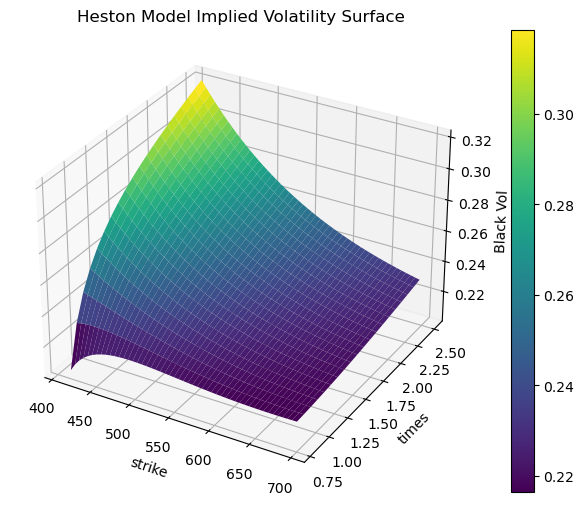

In [11]:
rho = -0.3
times = np.linspace(0.8,2.5,20)
sigma_bs = np.full((len(strikes),len(times)), np.nan)
for i,K in enumerate(strikes):
    for j,T in enumerate(times):
        call_heston = heston_call_price(S0, K, T, r, q, v0, kappa, theta, xi, rho)
        sigma_bs[i,j] = black_implied_vol(F, K, T, r, premium=call_heston, iscallput='call')
xT, xK = np.meshgrid(strikes,times)
xZ = sigma_bs.T
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xT, xK, xZ, cmap='viridis')
fig.colorbar(surf)
ax.set_ylabel('times')
ax.set_xlabel('strike')
ax.set_zlabel('Black Vol')
ax.set_title('Heston Model Implied Volatility Surface')
plt.show()
# Note 
#
answers["implied volatility shape is the same at all maturities"] = "no"
answers["implied volatility minimum is approximately"] = 0.22
answers["implied volatility maximum is approximately"] = 0.32
answers["do you expect higher implied volatility for low strikes?"] = "yes"
answers["do you expect lower implied volatility for high strikes?"] = "yes"
answers["do you expect lower implied volatility for low strikes and maturities?"] = "yes"
answers["Why do traders care about the volatility surface?"] = "its critical when they need to hedge strategies, and it reflects market dynamics" # edit here
answers["What does a steep volatility smile tell a trader?"] = "The IV of ITM and OTM options is significantly higher than ATM options, it suggests that the market is expecting large price movements"

## Local Volatility: The Dupire Formula

### Overview
The Dupire formula (1994) extracts a deterministic volatility function $ \sigma_{\text{LV}}(t, S_t) $ from option prices, assuming volatility varies with time and stock price. It’s a powerful tool for fitting market data and pricing exotic options.

### Learning Outcomes
- **Understand**: How local volatility links to observed option prices and differs from stochastic volatility.
- **Interpret**: Compare local and implied volatility surfaces to infer market expectations.
- **Apply**: Use market call prices to estimate $ \sigma_{\text{LV}} $, aiding hedging and risk management.

### Key Formula
$$ \sigma_{\text{LV}}(t, K)^2 = 2 \frac{\frac{\partial C}{\partial t} + q C + (r - q) K \frac{\partial C}{\partial K}}{K^2 \frac{\partial^2 C}{\partial K^2}} $$

### Introduction

The Dupire formula is a cornerstone of local volatility models in financial mathematics, enabling the extraction of a deterministic volatility function from European option prices. Unlike the Black-Scholes model’s constant volatility assumption, the local volatility model posits that volatility depends on both time $ t $ and stock price $ S_t $. Introduced by Bruno Dupire in 1994, this formula infers the local volatility, $ \sigma_{\text{LV}}(t, S_t) $, from call option market prices across strikes and maturities under a risk-neutral framework with constant risk-free rate $ r $ and equity repo rate/dividend yield $ q $. It provides a practical tool for pricing and hedging derivatives, allowing a fit to different black-scholes model volatilities observed for different times and strikes.

Here is a link to [Dupire's 1994 paper](https://www.scirp.org/reference/referencespapers?referenceid=1339339).

### Dupire Formula with Constant $ r $ and $ q $

For a stock following the stochastic differential equation (SDE) under the risk-neutral measure:
$$
dS_t = (r - q) S_t dt + \sigma_{\text{LV}}(t, S_t) S_t dW_t,
$$
where $ r $ is the constant risk-free rate, $ q $ is the constant equity repo rate and dividend yield, and $ W_t $ is a Brownian motion, the local volatility $ \sigma_{\text{LV}}(t, K) $ at time $ t $ and stock price $ S_t = K $ is:
$$
\sigma_{\text{LV}}(t, K)^2 = 2 \frac{\frac{\partial C}{\partial t}(t, K) + q C(t, K) + (r - q) K \frac{\partial C}{\partial K}(t, K)}{K^2 \frac{\partial^2 C}{\partial K^2}(t, K)},
$$
where $ C(t, K) $ is the price of a European call option with strike $ K $ and maturity $ T $ (with $ t $ as current time and $ T - t $ as time to maturity).

We can use call prices obtained from any stochastic model model or observed in the market to evaluate discrete estimates of the partial derivatives of $C(t_i,K_j)$ and compute $\sigma_{\text{LV}}(t_i,K_j)$.

### Link to Stochastic Volatility Models and Proof  

The proof below is advanced material, it is of educational interest because it not shows existence and unicityof a local volatility models based on call prices, but it shows a general property that any stochastic model of volatility must have expected stochastic volatility sqared equal to the local volatility square.

1. **Model Setup**:
   - Define the call option payoff $ (S_t - K)^+ $, where $ (x)^+ = \max(x, 0) $.
   - Use the SDE $ dS_t = (r - q) S_t dt + \sigma(t, S_t) S_t dW_t $.

2. **Generalized Derivatives**:
Tanaka's formula is Ito's formula applied on non smooth functions, using generalised derivatives. It is a convenient tool compute call prices in stochastic calculus.

   - Tanaka’s formula: $ d(S - K)^+ = 1_{\{S > K\}} dS + \frac{1}{2} \sigma(t, S)^2 S^2 \delta_{\{S = K\}} dt $.
   - $ d1_{\{S > K\}} = \delta_{\{S = K\}} = d_K(S) $, the Dirac delta at $ S = K $.

3. **Apply the SDE**:
   - Substitute $ dS_t $:
     $$
     d(S_t - K)^+ = 1_{\{S_t > K\}} [(r - q) S_t dt + \sigma(t, S_t) S_t dW_t] + \frac{1}{2} \sigma(t, S_t)^2 S_t^2 d_K(S_t) dt.
     $$

4. **Discount and Expectation**:
   - Use the discount factor $ D_t = e^{-r t} $, so $ C(t, K) = D_t E[(S_T - K)^+] $.
   - Compute $ d(D_t Y) $, take the risk-neutral expectation ($ E[dW_t] = 0 $):
     $$
     E[d(D_t C)] = 0 = D_t dY - r D_t Y dt.
     $$
   - Substitute $ Y=(S_t - K)^+ $:
     $$
     dC = -r C dt + E[1_{\{S_t > K\}} (r - q) S_t] dt + \frac{1}{2} K^2 E[\sigma(t, S_t)^2 | S_t = K] \frac{\partial^2 C}{\partial K^2} dt.
     $$

5. **Explicit the Drift Term from $C$**:
   - $ E[1_{\{S_t > K\}}(r-q) S_t] = (r - q) (C + K \frac{\partial C}{\partial K}) $, using $ S_t = (S_t - K) + K $.
   - Adjust:
     $$
     dC = -q C dt - (r - q) K \frac{\partial C}{\partial K} dt + \frac{1}{2} K^2 E[\sigma(t, S_t)^2 | S_t = K] \frac{\partial^2 C}{\partial K^2} dt.
     $$

6. **Solve for Local Volatility**:
   - Set $ dC = \frac{\partial C}{\partial t} dt $:
     $$
     \frac{\partial C}{\partial t} = -q C - (r - q) K \frac{\partial C}{\partial K} + \frac{1}{2} K^2 E[\sigma(t, S_t)^2 | S_t = K] \frac{\partial^2 C}{\partial K^2}.
     $$
   - Rearrange:
     $$
     E[\sigma(t, S_t)^2 | S_t = K] = \frac{\frac{\partial C}{\partial t} + q C + (r - q) K \frac{\partial C}{\partial K}}{\frac{1}{2} K^2 \frac{\partial^2 C}{\partial K^2}}.
     $$
   - At $ S_t = K $, this is $ \sigma_{\text{LV}}(t, K)^2 $, yielding the Dupire formula.

The denominator uses $ \frac{\partial^2 C}{\partial K^2} > 0 $ (positive density) for a valid local volatility. The positivity of the expression is actually an Arb-Free condition on the call price surface $C(t,K)$.



In [ ]:
call    = np.full((len(strikes), len(times)), np.nan)
for i,k in enumerate(strikes):
    for j,t in enumerate(times):
        F = S0*np.exp((r-q)*t)
        call[i,j] = black_formula(F, k, t, r, sigma_bs[i,j], iscallput='call')
dtimes  = np.diff(times)
dK      = np.diff(strikes)[0]
sigmaLV = np.full((len(strikes), len(times)), np.nan)
for i,k in enumerate(strikes):
    for j,t in enumerate(times):
        if i==0 or i==len(strikes)-1:
            continue
        dCdT   = (call[i,j+1]-call[i,j])/dtimes[j] if j<len(dtimes)-1 else (call[i,j]-call[i,j-1])/dtimes[j-1]
        dCdK   = (call[i+1,j]-call[i-1,j])/(2*dK)
        d2CdK2 = (call[i+1,j]-2*call[i,j]+call[i-1,j])/(dK**2)
        numerator   = dCdT+(r-q)*k*dCdK+q*call[i,j]
        denominator = .5*k*k*d2CdK2
        sigmaLV[i,j] = np.sqrt(numerator/denominator)
# # # Visualization
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.title("Black Vol Surface")
plt.contourf(times, strikes, sigma_bs, levels=20, cmap='viridis')
plt.colorbar()
plt.subplot(122)
plt.title("Local Vol Surface")
plt.contourf(times, strikes, sigmaLV, levels=20, cmap='viridis')
plt.colorbar()
plt.tight_layout()
plt.show()
answers["black volatility minimum on the surfaceis approximately"] = 0
answers["black volatility maximum on the surface is approximately"] = 0
answers["local volatility minimum on the surfaceis approximately"] = 0
answers["local volatility maximum on the surface is approximately"] = 0
answers["expected heston model sqrt(E(v(t)|S_t=K)) min on the surface is approximately"] = 0
answers["expected heston model sqrt(E(v(t)|S_t=K)) max on the surface is approximately"] = 0
answers["if call prices are the same for all t and K, is delta the same for heston and dupire?"] = "yes/no"
answers["if call prices are the same for all t and K, is theta the same for heston and dupire?"] = "yes/no"
answers["in theory, a dupire model can fit exactly call prices for any heston model"] = "yes/no"
answers["in theory, a heston model can fit exactly call prices for any dupire model"] = "yes/no"
answers["How does local volatility help structurers?"] = "" # edit here
answers["Why might local volatility differ from implied volatility?"] = ""

## Monte Carlo Simulation for Heston Model

### Overview
Monte Carlo simulation approximates Heston model dynamics by generating stock and variance paths, validating analytical solutions and exploring stochastic behavior.

### Learning Outcomes
- **Understand**: How simulation captures randomness in stock prices and volatility.
- **Analyze**: Compare Monte Carlo results to Fourier-based prices, identifying discrepancies.
- **Apply**: Assess implied volatility trends and terminal distributions for trading insights.



In [ ]:
def cholesky_2x2(rho):
    """Return Cholesky factor U for 2x2 correlation matrix with rho."""
    assert -1 <= rho <= 1, "rho must be in [-1, 1]"
    return np.array([[1, rho], 
                    [0, np.sqrt(1 - rho**2)]])

def check_std(t,dWt):
    Wt = np.cumsum(dWt,axis=1)
    stdWt = np.std(Wt,axis=0)
    plt.plot(t,stdWt[:,0],label="std W^1_t")
    plt.plot(t,stdWt[:,1],label="std W^2_t")
    plt.plot(t,np.sqrt(t),label="sqrt(t)")
    plt.legend()
    plt.title("Brownian Stdev Check")
    plt.show()  
    
T = max(times)
nsim,nT,dim = 10000,90,2
deltat  = T/nT
times   = np.linspace(0,T,nT+1)[1:]
print("check time step:",times[1]-times[0])
np.random.seed(42)
Z   = np.random.normal(loc=0, scale=np.sqrt(deltat), size=(nsim//2, nT, dim))
dZt = np.vstack([Z,-Z]) # antithetic sampling, independant brownians
A = cholesky_2x2(rho)
# Vectorized multiplication: dWt = A @ dZt[s,t,:] for all s,t
dWt = np.einsum('ij,sti->stj', A, dZt)  # correlated brownians (10000, 20, 2)
check_std(times,dWt)
print("cholesky check:",A.T@A)
print("dWt shape:", dWt.shape)
answers["expected std of dW2_t at t=0.5 is"] = 0
answers["dZ^1_t and dZ^2_t are correlated"] = "yes/no"
answers["dW^1_t and dW^2_t are correlated"] = "yes/no"
answers["When would a trader trust Monte Carlo over a formula?"] = ""
answers["Why would a MC implementation be chosen?"] = "" # edit here


### Heston Model Monte Carlo for $S_t$ and $v_t$

The Heston model describes the dynamics of a stock price $S_t = e^{x_t}$  as follows
$$dx_t = ((r-q) -\frac{1}{2} v_t) \, dt + \sqrt{v_t} dW_{1,t}$$
where its stochastic variance $v_t$ under the risk-neutral measure follows:
$$dv_t = \kappa (\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_{2,t}$$

We apply an euler scheme to compute $x_t, v_t$. The average variance $\frac{1}{t} \int_0^t v_s ds$ is computed to plot the variance of $x_t$ over a trajectory, and compute average standard deviations.

In [ ]:
x = np.zeros((nsim,nT+1))
v = np.zeros((nsim,nT+1))
x[:,0],v[:,0] = np.log(S0),v0
for i,t in enumerate(times):
    print("diffusing %f" % t, end="\r")
    v[:,i+1] = np.maximum(v[:,i] + kappa*(theta - v[:,i])*deltat + xi * np.sqrt(v[:,i]) * dWt[:,i,1],1e-12)
    x[:,i+1] = x[:,i] + (r-q-.5*v[:,i])*deltat + np.sqrt( v[:,i]) * dWt[:,i,0]
St = np.exp(x[:,1:])
F  = S0*np.exp((r-q)*times)
print("Feller condition is", 2*kappa*theta>xi**2)
# Create a trajectory figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
for isim in range(200):
    ax1.plot(times, St[isim,:], color="blue", alpha=0.05, label="simulated" if isim==0 else None)
ax1.plot(times, F, color="red", label="forward")
ax1.set_title("Stock Trajectories")
ax1.legend()
for isim in range(200):
    ax2.plot(times, np.sqrt(np.cumsum(v[isim, 1:])*deltat/times), color="blue", alpha=0.05, label="simulated" if isim==0 else None)
ax2.set_title("Average Stock Volatility over Trajectories")
ax1.set_xlabel("time")
ax2.set_xlabel("time")
ax1.set_ylabel("S_t=exp(x_t)")
ax2.set_ylabel("sigma_t=(1/t int_0^t v_s ds)^1/2")
ax2.axhline(y=np.sqrt(v0),label="sigma_0",color="red",linestyle=":")
ax2.axhline(y=np.sqrt(theta),label="sigma_infty",color="red")
ax2.legend()
plt.tight_layout()
plt.show()
# Create a terminal distribution figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.hist(x[:, -1], color="blue",bins=100,alpha=0.5)
ax1.set_title("ln(S_T) terminal values")
ax1.axvline(x=np.log(F[-1]),label="forward",color="red",linestyle="-")
ax2.hist(np.sqrt(np.sum(v[:,1:],axis=1)*deltat/times[-1]), color="blue",bins=100,alpha=0.5)
ax2.axvline(x=np.sqrt(v0),label="sigma_0",color="red",linestyle=":")
ax2.axvline(x=np.sqrt(theta),label="sigma_infty",color="red")
ax2.set_title("Average Trajectory Volatility")
ax1.set_xlabel("x_T=ln(S_T)")
ax2.set_xlabel("sigma_T=(1/T int_0^T v_t dt)^1/2")
ax1.set_ylabel("number of simulations")
ax2.set_ylabel("number of simulations")
ax2.legend()
ax1.legend()
plt.tight_layout()
plt.show()
answers["x_t distribution is"] = "gaussian/skewed left/skewed right"
answers["v_t trajectories are diffusing from theta to v_0"] = "yes/reverse"
answers["v_t drift with higher kappa is"] = "stronger/weaker"


In [ ]:
df = np.exp(-r*times)
strikes_sparse   = strikes[::5]
strikes_reshaped = strikes_sparse.reshape(1, 1, len(strikes_sparse))
St_reshaped = St.reshape(nsim, nT, 1)
# evaluate a nT x nK matrix of call prices
calls = np.mean(np.maximum(St_reshaped - strikes_reshaped, 0),axis=0)*df.reshape(nT,1)
F_mc  = np.mean(St,axis=0)
sigma_bs_mc = np.full((len(strikes_sparse),len(times)), np.nan)
for i,K in enumerate(strikes_sparse):
    for j,T in enumerate(times):
        sigma_bs_mc[i,j] = black_implied_vol(F_mc[j], K, T, r, premium=calls[j,i], iscallput='call')
# # Visualization
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.plot(times,F_mc,label="mc Forward",color="b")
plt.plot(times,F,label="Forward",color="red")
plt.legend()
plt.title("Forward and Simulated forward")
plt.subplot(122)
plt.title("MC Simulated Heston Vol Surface")
plt.contourf(times, strikes_sparse, sigma_bs_mc, levels=20, cmap='viridis')
plt.colorbar()
plt.tight_layout()
plt.show()
answers["volatility trends up or down with time?"] = "up/down"
answers["do the MC results confirm the Heston formula for t>1"] = "yes/no"
answers["do the MC results confirm the Heston formula for t<1"] = "yes/no"
answers["higher implied volatilities for smaller strike are expected with rho=-0.3"] = "yes/no"
answers["lower implied volatilities for higher strike are expected with rho=-0.3"] = "yes/no"
answers["Discrepancy, if any is due to"] = "programming error/numerical inaccuracy/no discrepancy"
answers["which implementation has suspicious shape for some maturities"] = "MC/FT/no discrepancy"


In [ ]:
# you need to edit this cell to edit MYEMAIL and MYKEY. running this cell will submit your answers
course = "mafs5330"
# import config
# config.createhash(answers,course)
# MYEMAIL = config.profemail[course]
# MYKEY = config.profapikey[course]
#edit line below when ready to post the answer, http status_code for succesful submission is 200

MYEMAIL  = 'rshao@connect.ust.hk' # <- EDIT email address that received api key from <mail.validation@mg.quantfinance.club>'
MYKEY = '46bb4348b44334e3277327c46999c668bc7db49a02fae092d32348136f5f3ad5'
import requests,json,time
def post_answer(question, answer):
    time.sleep(0.01)
    questionhash = {"black formula forward is": "885716c4a01ce286079a111b8b4a51c381696ce4d108e5dcdc9ca01f236ec9a3", "black formula implied volatility is": "d9f16d2d48b8b00b1c12f3b21ba30467e2cc9a4dc271295939611878b9d6eba8", "black formula atm strike (50% delta) is": "8ebe5bcd15952c937f60f4d5b4e08ca8a111a3aeedeccd3498f99965ed7d3d5c", "black scholes delta at forward is": "c23d7c8d3085420c606d782f74506ad53d18e580b3d55072ab974776bdbd0a68", "Why do traders use 25% and 75% delta strikes?": "979a2e59d8ba8f947a6ee30337031d52dd3f87ed582044d92827401e4e10e49f", "how does higher xi affect OTM put vol with same ATM?": "21be320e9e497d13d9f3b012fa7c449e1d8177521fe2281898a1548ed86e3dc7", "how does negative rho affect OTM put vol with same ATM?": "1c285154ae03a1ad594b44e794b91fee5a972946682ddd996d696b1657950d83", "How does a negative rho impact option pricing?": "b7700e21c19cb1dd5d3fd384f1d2a009d5335f563eda1276306213fa5b130734", "implied volatility smile shape if rho=0": "d965655433ef165efea2b9496339c06b9d469b20302f1fc31d3c9bd512e9b997", "implied volatility smile shape if rho=-15%": "0f49d62055e4c092f3407f16215f0861f351320275a55039d28b93770258ad5f", "implied volatility smile shape if rho=-35%": "b9653e2b54eed6ac3cc990118c057c4e51a03435a3a431d6cf4c2e51ca66d48a", "implied volatility drift if v0<theta": "018ba37de7ed4101809d839f6cb2c4fa99d1094d0b3dcfcf608edab46ffaacc9", "implied volatility drift if v0>theta": "428c5ff9f62a47526ca7f95265535038b3ed2e1c5983dc976d15036bc9455200", "implied volatility smile if xi=0 is": "b42b0de7abe7917c5fc04f4b0ea26c1b75a29da382bc23a519f0559cedb30eb3", "for rho=0, implied volatility ATM is": "c6989ab3514f18cf57c058893fe53250ba6593d2c9497f148d13725a7abaa77f", "for rho=-30%, implied volatility ATM is": "f3a0600da90d449c50f32a306752e48d9d7850bdaa7efaba36b25437b4057191", "for rho=0, implied volatility @25% put delta is": "f888ff5bd11e290a4bfd25aea77a489f98aedf78567046b69f4f9fdb5fc8bd39", "for rho=-30%, implied volatility @25% put delta is": "e359df84ac70efe40620dff53544430803bf2f5a2e8c410caf4bd7845f66c847", "implied volatility shape is the same at all maturities": "e53c37ee1e40d403603ae8264ee968b7f0b8e4d315c0ee59c2ec648f4fc00b85", "implied volatility minimum is approximately": "63663a9b1597ccf97e383db7ccd1893f011478b2cb24ef3473f5ee2383ff8a3e", "implied volatility maximum is approximately": "a51323ef2582ca5c665f0e23c8a84eec09d1ca7b71ff9e8437ad07c57c1f1f30", "do you expect higher implied volatility for low strikes?": "a8a48bee3927af9f6b6eb7e37d6fe69468b4ff3ab7bb9d5d7657de553eb38d72", "do you expect lower implied volatility for high strikes?": "57010d747d294dbe609fb843f37e02aac9348d7049db70c327d8063891f201bc", "do you expect lower implied volatility for low strikes and maturities?": "51de2b37c6dca630ecb4bd7a618ef30b0a0547b5906675507a10297c3cef88c9", "Why do traders care about the volatility surface?": "5dbc47a80f937814c7a0e9343c40afb82224255bbbede0ebf95461ae07256dd5", "What does a steep volatility smile tell a trader?": "60e9cc03c4558ce32059731048ff119b6b5a78bd92978411b96f9beadc95d9f2", "black volatility minimum on the surfaceis approximately": "0a4c4c85e528cffa2531afaae0785612cd6aa8a0c4cc65f94df3f4b211b96740", "black volatility maximum on the surface is approximately": "a2304251d98ea6e4fb64ae84a7c2fbbe2ef835a5e44faf05add2704286b2bcbc", "local volatility minimum on the surfaceis approximately": "b975ffcc79e4e9e044c2a9cf42bbad337957e0c18b15059ec34242109deccb85", "local volatility maximum on the surface is approximately": "5e89602663634dc03df9f620724289cf1b1d796ab76660d33751df88d98dcf57", "expected heston model sqrt(E(v(t)|S_t=K)) min on the surface is approximately": "6d1765c1e07b9b651f568ab3d78f568217e7c811815cd136f8af6b33539c2a1c", "expected heston model sqrt(E(v(t)|S_t=K)) max on the surface is approximately": "2001511ec38ed5c1fba9d870d904c9db6a5a7f055865c39f0069e297c93aa913", "in theory, a dupire model can fit exactly call prices for any heston model": "4e305231e21b6846198f3c73c9caa4603242edde2f3fb83edc287e74d9c66d7e", "in theory, a heston model can fit exactly call prices for any dupire model": "59a241f64e1e5c26a761a14f7826caf97abad2bb99fce8f09e23473ba6f88e01", "if call prices are the same for all t and K, is delta the same for heston and dupire?": "fe4c0dc60c387f14dc180e8d52b684a33b558bdbe9885102b596857b0c9eee58", "if call prices are the same for all t and K, is theta the same for heston and dupire?": "7fb8d0718c8e62414ce4065e30cdc872c24f365d1b61cc2c0e42b27a4fc74832", "How does local volatility help structurers?": "a8063b1fe61ed84597a3f105e211d1e74dd0565c9c23dd087c2e48041d72f71c", "Why might local volatility differ from implied volatility?": "6fb4318093e520cca6d80d51ec6fddd0f843727401104c78c2cc9d615149cf8f", "expected std of dW2_t at t=0.5 is": "37d5a896c7339d7923ac1429e3b5109f853c3ad34bb4bc22260b93f8f1fadfdc", "dZ^1_t and dZ^2_t are correlated": "db2acc31d842a1ed9586edc756ae089b96942edc898efbeaa3d25327a2cbe541", "dW^1_t and dW^2_t are correlated": "e5ae439b95d541a9e0fe4db0eefaeeb683aff222cc399d29b3c153ddd442508a", "When would a trader trust Monte Carlo over a formula?": "44b0e6298676c2d1280527045e3c7221a000ff72480196a60ddda6970e771bbf", "Why would a MC implementation be chosen?": "bcded786ca8f7f87ca77c9e2278214427cfd4fdd5f270e3878251b9dea98ad85", "x_t distribution is": "ee881298fe75302a8bd814a7f49a4bcd3e722d3c4e5920f91eb61418f7ad9b89", "v_t trajectories are diffusing from theta to v_0": "58aa7ae0197312d30d71f56307063b6c7dfa36c4e192022ba4200a5db13ed2d9", "v_t drift with higher kappa is": "09e03288774e57a704371ef5b900e0f58f3407a32215597446a8b95e28463bd3", "volatility trends up or down with time?": "10568e4fa804ebcf8647309ed17ac9fc1ec64359c22ee55ce237bc89e4ccb717", "do the MC results confirm the Heston formula for t>1": "ef0e88fd6c98100c47a8646e9b3aa5d5532ceb75d7e9e28312332eb24a7a7b46", "do the MC results confirm the Heston formula for t<1": "e16d07a2fccd2eff5c0a997bf4a8f1cc3475c9b83c428c0552364c414a3ad12e", "higher implied volatilities for smaller strike are expected with rho=-0.3": "d68ce27578ad2b1f90b2cdcadc958e21c92c5aacf58cc23b485244337bf495d6", "lower implied volatilities for higher strike are expected with rho=-0.3": "adb33d5c7ceed9a1df6b73166d7ac1a82082851e7479ab1ef2f8b56e67219191", "Discrepancy, if any is due to": "c5e5139ab703ccba190ce2a73e937786e37acea912339e34191dc896e70adacf", "which implementation has suspicious shape for some maturities": "ccc4ab28f62e8260ebe165d22df9c5ccc322c7cbee25485a8f2d1f6f4f936c7e"}
    return requests.post(f"https://www.quantfinance.club/{course}",data={'user':MYEMAIL,'mykey':MYKEY,'questionid':question,'answer':answer,'questionkey':questionhash[question]})
nbAnswers = 53
if len(answers)!=nbAnswers:
    raise Exception(f"There are {len(answers)} answers, should be {nbAnswers}. You can comment this check if you want to submit partial answers.")
for q,a in answers.items():
    x = post_answer(q, a)
    if x.status_code!=200:
        if x.status_code==401:
            raise Exception("API Key Authentication failed: please make sure the variables MYEMAIL and MYKEY are set")
        raise Exception("submission error with code:",x.status_code)
    else:
        print("submitted answer to %s=%s" % (q,str(a)))
print(f"check your latest submitted answers on:\nhttps://www.quantfinance.club/{course}_myanswers?email={MYEMAIL}&apikey={MYKEY}")